In [ ]:
#!pip install openpyxl


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#!pip install matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
df = pd.read_excel(r"C:\Users\Admin\Downloads\online+retail\Online Retail.xlsx")
print(df)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  CustomerID         Country  
0      

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
#1. To check sum of null values before drop
df['CustomerID'].isnull().sum()

np.int64(135080)

In [10]:
df.shape

(541909, 8)

In [11]:
#Removing rows where CustomerID is null
df = df.dropna(subset=['CustomerID'])

In [12]:
#To check sum of null values
df['CustomerID'].isnull().sum()

np.int64(0)

In [13]:
df.shape

(406829, 8)

In [14]:
# 2. Remove cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [15]:
df.shape

(397924, 8)

In [16]:
# 3. Remove negative quantities
df = df[df['Quantity'] > 0]

In [17]:
df.shape

(397924, 8)

In [18]:
# 4. Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [19]:
#5. Fixing the Date
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [20]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [21]:
#6. Getting Snapshot Date
snapshot_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [22]:
#7. RFM Calculation
rfm=df.groupby('CustomerID').agg(
    Recency=('InvoiceDate',lambda x:(snapshot_date-x.max()).days),
    Frequency=('InvoiceNo','nunique'),
    Monetary=('TotalPrice','sum')
    ).reset_index()

In [23]:
print(rfm.head())

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


In [24]:
#8. Giving each Customer a score
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])

In [25]:
print(rfm.columns.tolist())

['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score']


In [26]:
#9. Combining scores into one code
rfm['RFM_Score']=rfm['R_Score'].astype(str)+rfm['F_Score'].astype(str)+rfm['M_Score'].astype(str)
print(rfm.head())




   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0     12346.0      326          1  77183.60       1       1       5       115
1     12347.0        2          7   4310.00       5       5       5       555
2     12348.0       75          4   1797.24       2       4       4       244
3     12349.0       19          1   1757.55       4       1       4       414
4     12350.0      310          1    334.40       1       1       2       112


In [27]:
#10. Assigning Segment Names
# 10. Assigning Segment Names (11 segments)
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])

    if r >= 4 and f >= 4:
        return 'Champion'
    elif r >= 4 and f <= 1:
        return 'New Customer'
    elif r == 3 and f == 1:
        return 'Promising'
    elif r == 3 and f == 2:
        return 'Need Attention'
    elif r == 2 and f == 2:
        return 'About to Sleep'
    elif r <= 1 and f >= 4:          # ← before At Risk
        return 'Cannot Lose Them'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r >= 3 and f <= 3:          # ← after At Risk
        return 'Potential Loyalist'
    elif r >= 2 and f >= 3:
        return 'Loyal Customer'
    elif r <= 2 and f <= 2:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)
print(rfm['Segment'].value_counts())

Segment
Champion              1121
Hibernating            867
Potential Loyalist     665
At Risk                601
Loyal Customer         329
About to Sleep         208
Need Attention         185
Promising              165
New Customer           138
Cannot Lose Them        60
Name: count, dtype: int64


In [28]:
#11a. Checking segment counts
print(rfm['Segment'].value_counts())

Segment
Champion              1121
Hibernating            867
Potential Loyalist     665
At Risk                601
Loyal Customer         329
About to Sleep         208
Need Attention         185
Promising              165
New Customer           138
Cannot Lose Them        60
Name: count, dtype: int64


In [29]:
# 11b. Segment Profile Table
segment_profile = rfm.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(2).reset_index()
segment_profile['Revenue_%'] = (segment_profile['Total_Revenue'] / segment_profile['Total_Revenue'].sum() * 100).round(2)
segment_profile = segment_profile.sort_values('Total_Revenue', ascending=False)
print(segment_profile)

              Segment  Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
3            Champion       1121        13.00          10.05       5238.15   
5      Loyal Customer        329        48.97           5.72       2461.68   
1             At Risk        601       142.39           3.27       1256.31   
8  Potential Loyalist        665        26.40           2.10       1004.66   
4         Hibernating        867       240.53           1.05        472.69   
0      About to Sleep        208       116.56           1.32        554.39   
6      Need Attention        185        51.89           1.31        487.00   
2    Cannot Lose Them         60       233.27           4.90       1189.89   
9           Promising        165        53.08           1.00        418.21   
7        New Customer        138        18.05           1.00        367.94   

   Total_Revenue  Revenue_%  
3     5871961.53      65.89  
5      809892.01       9.09  
1      755044.94       8.47  
8      668101.38     

In [30]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

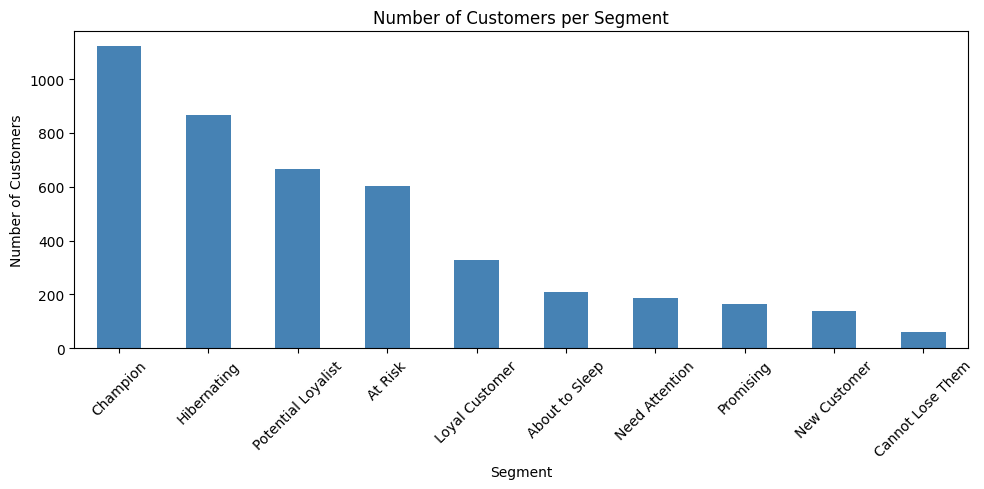

In [31]:
#12. Chart1: Customer Count Per Segment
plt.figure(figsize=(10,5))
rfm['Segment'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Number of Customers per Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart1_segment_count.png')
plt.show()

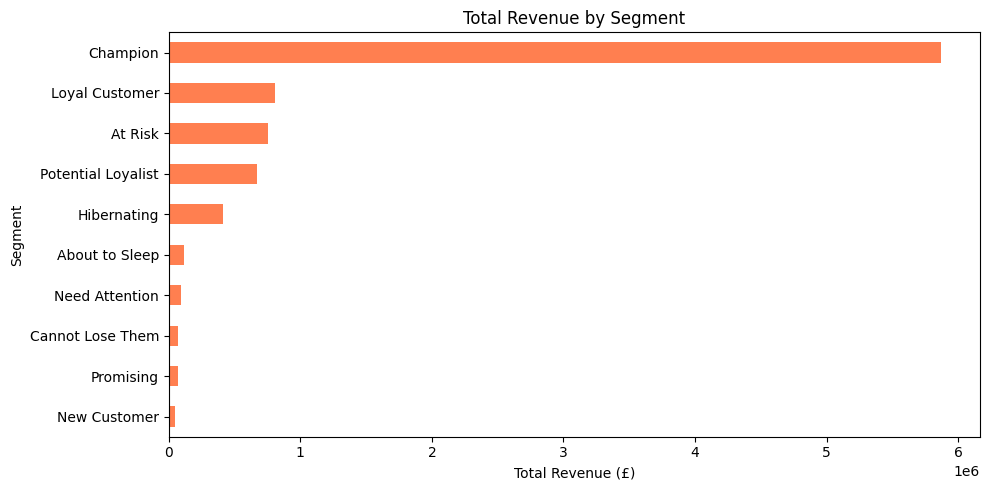

In [32]:
#13. Chart2: Revenue per Segment(Horizontal Bar)
plt.figure(figsize=(10,5))
rfm.groupby('Segment')['Monetary'].sum().sort_values().plot(kind='barh', color='coral')
plt.title('Total Revenue by Segment')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('chart2_revenue.png')
plt.show()

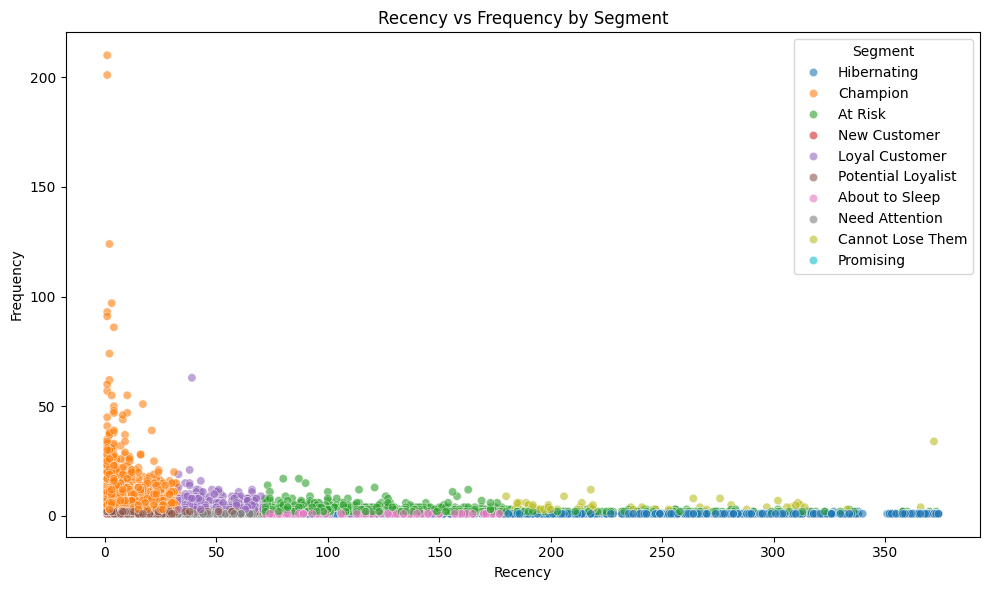

In [33]:
#14. Chart3: ScatterPlot(Recency vs Frequency)
plt.figure(figsize=(10,6))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', 
                hue='Segment', alpha=0.6)
plt.title('Recency vs Frequency by Segment')
plt.tight_layout()
plt.savefig('chart3_scatter.png')
plt.show()

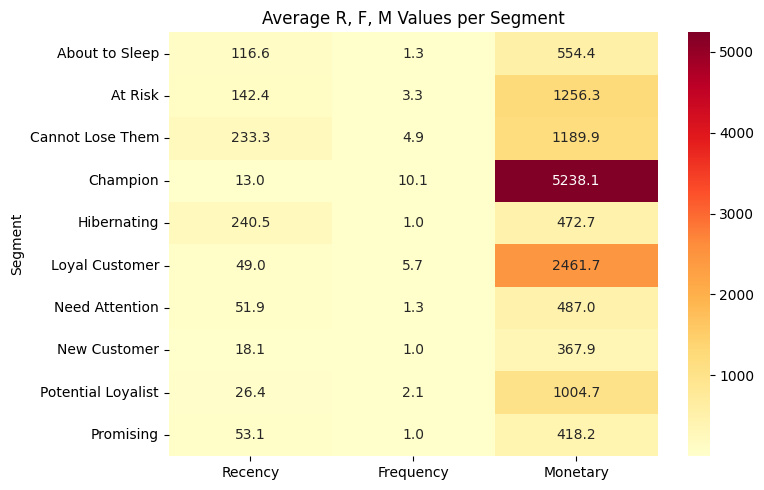

In [34]:
#15. Chart4: RFM Score Heatmap
plt.figure(figsize=(8,5))
heatmap_data = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Average R, F, M Values per Segment')
plt.tight_layout()
plt.savefig('chart4_heatmap.png')
plt.show()

In [35]:
# Clean column names before export
rfm.columns = [col.replace('\n', ' ') for col in rfm.columns]
segment_profile.columns = [col.replace('\n', ' ') for col in segment_profile.columns]

In [36]:

# 15. Export to Excel (for Power BI) with KPI Summary
with pd.ExcelWriter('RFM_Output_Final.xlsx', engine='openpyxl') as writer:
    
    # Sheet 1 — clean RFM data
    rfm.to_excel(writer, sheet_name='RFM_Data', index=False)
    
    # Sheet 2 — segment profile
    segment_profile.to_excel(writer, sheet_name='Segment_Profile', index=False)
    
    # Sheet 3 — KPI Summary
    kpi_data = {
        'KPI': [
            'Total Customers',
            'Total Revenue (£)',
            'Avg Spend per Customer (£)',
            'Total Segments',
            'Champion Customers',
            'Champion Revenue %',
            'At Risk Customers',
            'At Risk Revenue (£)',
            'Hibernating Customers',
            'Snapshot Date',
            'Data Source'
        ],
        'Value': [
            rfm['CustomerID'].nunique(),
            round(rfm['Monetary'].sum(), 2),
            round(rfm['Monetary'].mean(), 2),
            rfm['Segment'].nunique(),
            len(rfm[rfm['Segment'] == 'Champion']),
            round(rfm[rfm['Segment'] == 'Champion']['Monetary'].sum() / rfm['Monetary'].sum() * 100, 2),
            len(rfm[rfm['Segment'] == 'At Risk']),
            round(rfm[rfm['Segment'] == 'At Risk']['Monetary'].sum(), 2),
            len(rfm[rfm['Segment'] == 'Hibernating']),
            str(df['InvoiceDate'].max().date() + pd.Timedelta(days=1)),
            'UCI Online Retail Dataset'
        ],
        'Insight': [
            'Unique customers analysed',
            'Across all valid transactions',
            'Average monetary value per customer',
            'Customer groups identified',
            'High-value active customers',
            'Champions drive most revenue',
            'Need urgent win-back campaign',
            'Revenue at risk of churning',
            'Send re-engagement offers',
            'Reference date for Recency',
            'UK e-commerce 2010-2011'
        ]
    }
    
    kpi_df = pd.DataFrame(kpi_data)
    kpi_df.to_excel(writer, sheet_name='KPI_Summary', index=False)

print("Done! Exported 3 sheets: RFM_Data, Segment_Profile, KPI_Summary")
print(f"\nKPI Preview:")
print(kpi_df.to_string(index=False))

Done! Exported 3 sheets: RFM_Data, Segment_Profile, KPI_Summary

KPI Preview:
                       KPI                     Value                             Insight
           Total Customers                      4339           Unique customers analysed
         Total Revenue (£)                 8911407.9       Across all valid transactions
Avg Spend per Customer (£)                   2053.79 Average monetary value per customer
            Total Segments                        10          Customer groups identified
        Champion Customers                      1121         High-value active customers
        Champion Revenue %                     65.89        Champions drive most revenue
         At Risk Customers                       601       Need urgent win-back campaign
       At Risk Revenue (£)                 755044.94         Revenue at risk of churning
     Hibernating Customers                       867           Send re-engagement offers
             Snapshot Date      